# A* Search Algorithm (Shortest-Cost Pathfinding)

A* Search is an informed search algorithm that finds the shortest path between two points in a grid-based environment.

It combines actual path cost with a heuristic estimate to efficiently guide the search toward the goal.

In this Flood Evacuation & Rescue System, A* is used to find the shortest path from the rescue team to the nearest victim and then from the victim to the shelter.

# Key Components of A* Search

 **1. State Representation:** Each state represents a cell in the grid defined by coordinates:

**State = (row, column)**

 **2. Cost Function:** A* evaluates each node using:
 
f(n) = g(n) + h(n)

Where:

- **g(n):** Actual cost from the start node to the current node  
- **h(n):** Heuristic estimate (Manhattan distance) to the goal  
- **f(n):** Total estimated cost of the path through node n  


**3. Heuristic Function:** For grid-based movement, the Manhattan distance is used:

h(n) = |x1 - x2| + |y1 - y2|

This estimates the number of steps required to reach the goal.


 **4. Priority Queue:** A priority queue (min-heap) is used to always expand the node with the lowest **f(n)** value first.

This ensures that the most promising paths are explored first.


## Implementation Steps

**1. Initialize the Search**

- Start from the rescue team's location  
- Push start node into priority queue  
- Set g(n) = 0  
- Initialize visited set and parent dictionary  


**2. Search Loop**

While the priority queue is not empty:

- Pop node with smallest f(n)  
- If goal is reached → reconstruct path  
- Otherwise explore all valid neighbors  
- For each neighbor:
  - Compute g(n), h(n), f(n)
  - Update if a better path is found  
- Push neighbor into priority queue  


**3. Path Reconstruction**

Once goal is reached:

- Trace back using parent pointers  
- Reverse the path to get start → goal route  


**4. No Path Handling**

If the priority queue becomes empty without reaching the goal:

- Return that no valid path exists 


# Complete Rescue Operation using A*

The system runs A* in two phases:

**Phase 1:** Rescue Team → Nearest Victim

Multi-Goal A* finds and reaches the closest victim.

**Phase 2:** Victim → Shelter

Standard A* computes the shortest path to the shelter.


 **Rescue Flow**

Rescue Team → Nearest Victim → Shelter

In [1]:
%matplotlib inline
from collections import deque
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

sys.path.append(os.path.abspath(".."))

from Environment.grid import *


VICTIM:
[(18, 6), (17, 8), (15, 10)]

SHELTER:
(18, 18)

FLOOD ORIGINS:
[(9, 9), (9, 10), (10, 9), (10, 10), (11, 9), (11, 10), (12, 9), (12, 10), (15, 8), (15, 9), (16, 8), (16, 9), (17, 8), (17, 9)]

NEIGHBORS OF VICTIM:
(18, 6): [(17, 6), (19, 6), (18, 5), (18, 7)]
(17, 8): [(16, 8), (18, 8), (17, 7), (17, 9)]
(15, 10): [(14, 10), (16, 10), (15, 9), (15, 11)]

CELL INFO (9,9):
{'type': 2, 'water_level': 0.55, 'passable': True}

MOVEMENT COST OF (8,8):
1.0

IS (3,3) PASSABLE?
False


# A* Algorithm Implementation

The A* search algorithm explores cells based on their f(n) value, where:

f(n)=g(n)+h(n)

**g(n):** Actual cost from the start node to the current node
**h(n):** Heuristic estimate (Manhattan distance) from the current node to the goal

**A priority queue** (min-heap) is used so that the cell with the lowest f(n) value is explored first.

The algorithm always expands the most promising node by combining:

the cost already spent (g(n))
the estimated remaining distance (h(n))

A **parent dictionary** is maintained to track the path. Once the goal node is reached, the algorithm traces back through parent nodes to reconstruct the complete optimal path from start to goal.

In [2]:
# =====================================================
# A* SEARCH
# =====================================================

import heapq

def astar(start, goal):

    open_list = []

    heapq.heappush(
        open_list,
        (0, start)
    )

    visited = set()

    parent = {}

    parent[start] = None

    g_cost = {}

    g_cost[start] = 0

    while open_list:

        current_f, current = heapq.heappop(
            open_list
        )

        if current in visited:
            continue

        visited.add(current)

        if current == goal:

            path = []

            node = current

            while node is not None:

                path.append(node)

                node = parent[node]

            path.reverse()

            return path

        for neighbor in get_neighbors(current):

            nr, nc = neighbor

            tentative_g = (
                g_cost[current]
                +
                get_cost(nr, nc)
            )

            if (
                neighbor not in g_cost
                or
                tentative_g < g_cost[neighbor]
            ):

                g_cost[neighbor] = tentative_g

                h_cost = heuristic(
                    neighbor,
                    goal
                )

                f_cost = (
                    tentative_g
                    +
                    h_cost
                )

                parent[neighbor] = current

                heapq.heappush(
                    open_list,
                    (
                        f_cost,
                        neighbor
                    )
                )

    return None

# Multi-Goal A*

Since there can be multiple victims on the grid, a multi-goal version of A* is used.

Instead of targeting a single fixed goal, the search considers a list of victim locations and stops as soon as any one of them is reached.

The heuristic (heuristic_multi) estimates the distance to the **nearest victim** from the current position, helping the algorithm prioritize the most promising path.

This approach ensures faster discovery of a reachable victim by dynamically guiding the search toward the closest goal.

The function returns both the path and the specific victim cell that was reached during the search.
def risk_astar_multi_goal(start, goals):

In [3]:
# =====================================================
# A* MULTI GOAL
# =====================================================

def astar_multi_goal(start, goals):

    open_list = []

    heapq.heappush(
        open_list,
        (0, start)
    )

    visited = set()

    parent = {}

    parent[start] = None

    g_cost = {}

    g_cost[start] = 0

    goal_set = set(goals)

    while open_list:

        current_f, current = heapq.heappop(
            open_list
        )

        if current in visited:
            continue

        visited.add(current)

        if current in goal_set:

            path = []

            node = current

            while node is not None:

                path.append(node)

                node = parent[node]

            path.reverse()

            return path, current

        for neighbor in get_neighbors(current):

            nr, nc = neighbor

            tentative_g = (
                g_cost[current]
                +
                get_cost(nr, nc)
            )

            if (
                neighbor not in g_cost
                or
                tentative_g < g_cost[neighbor]
            ):

                g_cost[neighbor] = tentative_g

                nearest_goal = min(
                    goals,
                    key=lambda goal:
                    heuristic(
                        neighbor,
                        goal
                    )
                )

                h_cost = heuristic(
                    neighbor,
                    nearest_goal
                )

                f_cost = (
                    tentative_g
                    +
                    h_cost
                )

                parent[neighbor] = current

                heapq.heappush(
                    open_list,
                    (
                        f_cost,
                        neighbor
                    )
                )

    return None, None

# Rescue Team Start Position

The rescue team begins from the top-left corner of the environment grid.

The objective is to locate and reach a victim using the A* Search Algorithm.


In [4]:
start = (0, 0)

# Multiple victims -> Multi-goal A*
path_to_victim, found_victim = astar_multi_goal(
    start,
    victims
)

# Shelter is a single goal -> Normal A*
path_to_shelter = astar(
    found_victim,
    shelter
)

if path_to_victim and path_to_shelter:

    full_path = (
        path_to_victim
        +
        path_to_shelter[1:]
    )

    print(
        "Nearest Victim:",
        found_victim
    )

    print(
        "Path to Victim:",
        len(path_to_victim)-1,
        "steps"
    )

    print(
        "Path to Shelter:",
        len(path_to_shelter)-1,
        "steps"
    )

    print(
        "Total Rescue Path:",
        len(full_path)-1,
        "steps"
    )

else:

    print(
        "No valid rescue path found."
    )

Nearest Victim: (18, 6)
Path to Victim: 26 steps
Path to Shelter: 12 steps
Total Rescue Path: 38 steps


# Execute A* Search

The A* algorithm is executed to find an optimal path from the rescue team to the nearest victim while considering water depth costs.

After locating the victim, the path is reconstructed and displayed.

In [5]:
path_to_victim, found_victim = astar_multi_goal(
    start,
    victims
)

path_to_shelter = astar(
    found_victim,
    shelter
)

if path_to_victim:

    print("Path Found!")
    print()

    for p in path_to_victim:
        print(p)

    print()

    print(
        "Total Steps:",
        len(path_to_victim)-1
    )

else:

    print("No Path Found!")

if path_to_shelter:

    print("Path Found!")
    print()

    for p in path_to_shelter:
        print(p)

    print()

    print(
        "Total Steps:",
        np.sum([
            len(path_to_victim)-1,
            len(path_to_shelter)-1
        ])
    )

Path Found!

(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(0, 5)
(0, 6)
(1, 6)
(2, 6)
(3, 6)
(4, 6)
(5, 6)
(6, 6)
(7, 6)
(8, 6)
(9, 6)
(10, 6)
(11, 6)
(11, 7)
(12, 7)
(13, 7)
(14, 7)
(15, 7)
(16, 7)
(17, 7)
(17, 6)
(18, 6)

Total Steps: 26
Path Found!

(18, 6)
(18, 7)
(18, 8)
(18, 9)
(18, 10)
(18, 11)
(18, 12)
(18, 13)
(18, 14)
(18, 15)
(18, 16)
(18, 17)
(18, 18)

Total Steps: 38


# A* Rescue Movement Simulation

To visualize the rescue operation, the rescue team moves step-by-step along the path generated by A*.

The simulation updates the rescue team’s position at each time step until the victim is reached.

Unlike simple shortest-path visualization, the movement ensures that the agent follows the optimal path computed by A*, demonstrating how the algorithm guides real-time navigation toward the target.

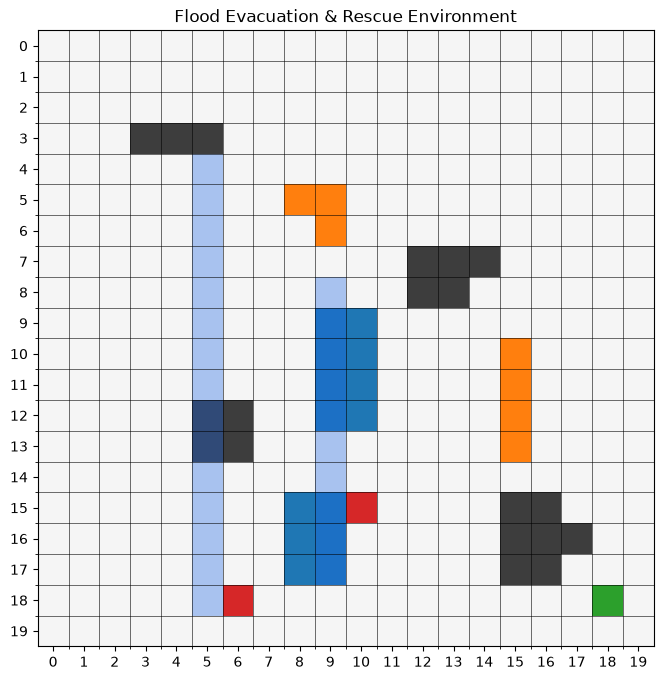

In [6]:
display_grid(save_image=False)

In [7]:
# =====================================================
# TEST A* (START TO NEAREST VICTIM)
# =====================================================

start = (0, 0)

path_to_victim, found_victim = astar_multi_goal(start, victims)

print("\nPATH TO VICTIM (A*):")
print(path_to_victim)

print("\nNearest Victim:", found_victim)
print("Steps:", len(path_to_victim)-1)


PATH TO VICTIM (A*):
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 6), (9, 6), (10, 6), (11, 6), (11, 7), (12, 7), (13, 7), (14, 7), (15, 7), (16, 7), (17, 7), (17, 6), (18, 6)]

Nearest Victim: (18, 6)
Steps: 26


In [8]:
# =====================================================
# STAGE 2: RISK-A* PATH TO VICTIM
# =====================================================

def display_astar_path_to_victim(path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    for r, c in path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="cyan",
                alpha=0.4
            )
        )

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 2: Victim Found (A* Path)"
    )

    if save_image:

        plt.savefig(
            "../images/astar_stage2_victim_found.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: astar_stage2_victim_found.png"
        )

    plt.show()


Image Saved: astar_stage2_victim_found.png


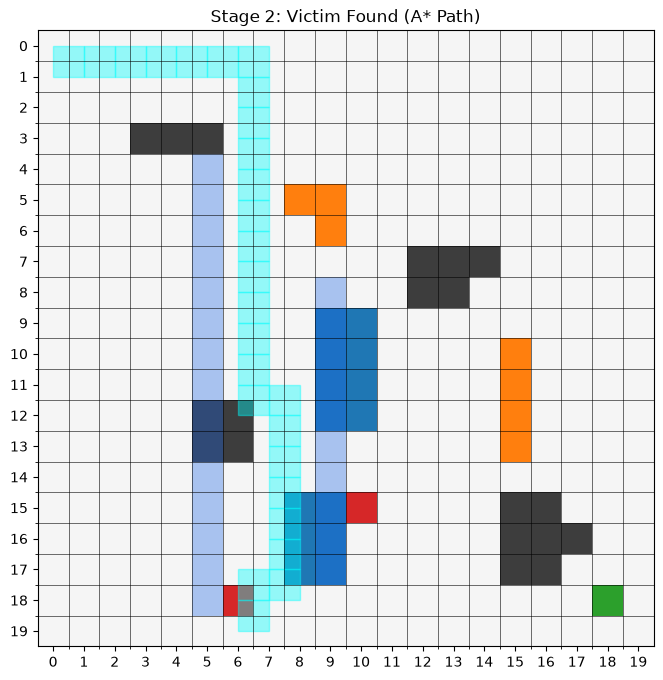

In [9]:
display_astar_path_to_victim(path_to_victim)

In [10]:
# =====================================================
# STAGE 3: FULL RESCUE PATH (VICTIM TO SHELTER) - RISK-A*
# =====================================================

def display_full_rescue_path(full_path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    for r, c in full_path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="green",
                alpha=0.4
            )
        )

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 3: Full Rescue Completed (A*)"
    )

    if save_image:

        plt.savefig(
            "../images/astar_stage3_full_rescue.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: astar_stage3_full_rescue.png"
        )

    plt.show()


Image Saved: astar_stage3_full_rescue.png


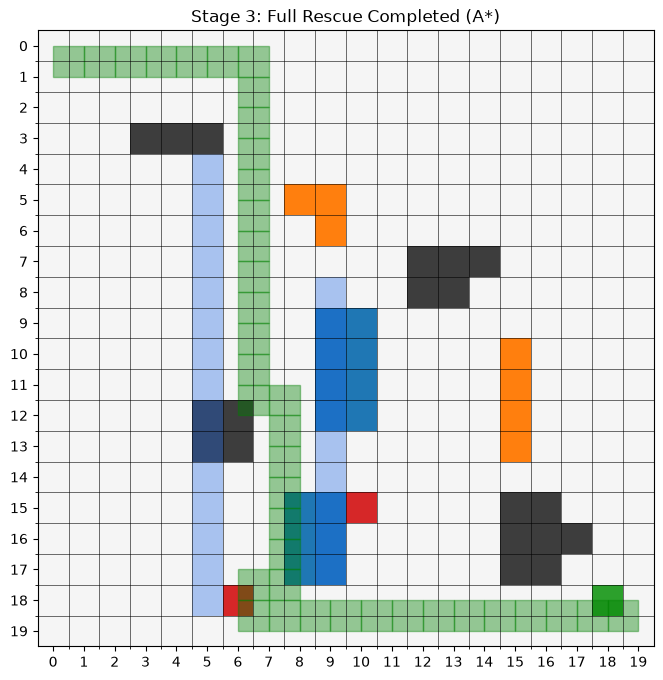

In [11]:
display_full_rescue_path(full_path)

In [12]:
reset_grid()